# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset ini merupakan AI Impact on Students — Academic & Well-being Dataset yang berisi data 50.000 mahasiswa. Dataset ini menangkap bagaimana penggunaan Generative AI memengaruhi performa akademik dan kesehatan mental. Tujuan dari eksperimen ini adalah untuk melakukan klasifikasi tingkat risiko burnout mahasiswa (Burnout_Risk_Level) berdasarkan fitur akademik, penggunaan AI, dan kebiasaan belajar."


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## Konfigurasi visualisasi

In [81]:
sns.set_theme(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [82]:
file_name = "ai_student_impact_dataset (1).csv"

try:
    # Download dataset terlebih dahulu
    path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")
    print("Path to dataset files:", path)

    # Coba baca file dari hasil download
    file_path = os.path.join(path, file_name)
    df = pd.read_csv(file_path)
    print("Berhasil memuat data dari Kagglehub!")

except FileNotFoundError:
    # Fallback jika file tidak ditemukan
    # Memisahkan string print agar aman jika variabel 'path' sebelumnya gagal terbentuk
    fallback_path = os.path.join("..", file_name)
    print(
        f"File tidak ditemukan di path Kaggle. Mencoba membaca dari parent directory: {fallback_path}"
    )

    df = pd.read_csv(fallback_path)
    print("Berhasil memuat data dari parent directory!")

# Menampilkan 5 baris pertama
df.head()

Path to dataset files: /Users/andilukman/.cache/kagglehub/datasets/laveshjadon/ai-impact-on-students/versions/1
Berhasil memuat data dari Kagglehub!


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [84]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [85]:
target_col = "Burnout_Risk_Level"

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("Student_ID")

cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
cat_cols.remove(target_col)

print(f"Target Columns:\n")
print(target_col)
print(f"\nNumerical Columns:\n")
print(*num_cols, sep="\n")
print(f"\nCategorical Columns:\n")
print(*cat_cols, sep="\n")

Target Columns:

Burnout_Risk_Level

Numerical Columns:

Pre_Semester_GPA
Weekly_GenAI_Hours
Tool_Diversity
Traditional_Study_Hours
Perceived_AI_Dependency
Anxiety_Level_During_Exams
Post_Semester_GPA
Skill_Retention_Score

Categorical Columns:

Major_Category
Year_of_Study
Primary_Use_Case
Prompt_Engineering_Skill
Paid_Subscription
Institutional_Policy


## Pengecekan Keseimbangan Target

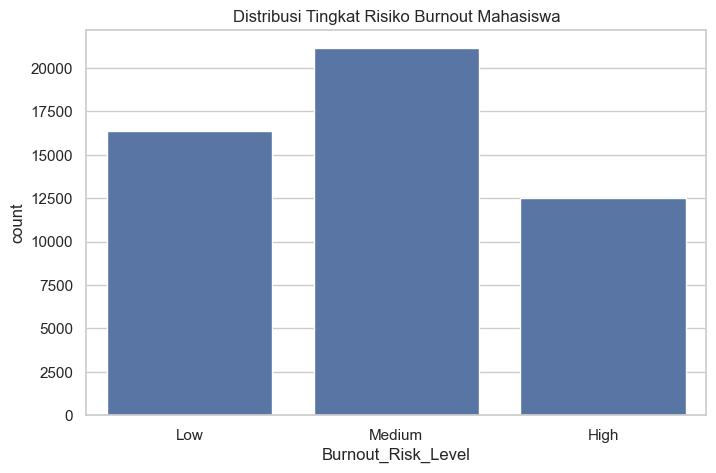

In [86]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Burnout_Risk_Level", order=["Low", "Medium", "High"])
plt.title("Distribusi Tingkat Risiko Burnout Mahasiswa")
plt.show()

## Histogram Fitur Numerik

Menampilkan Histogram untuk fitur numerik...


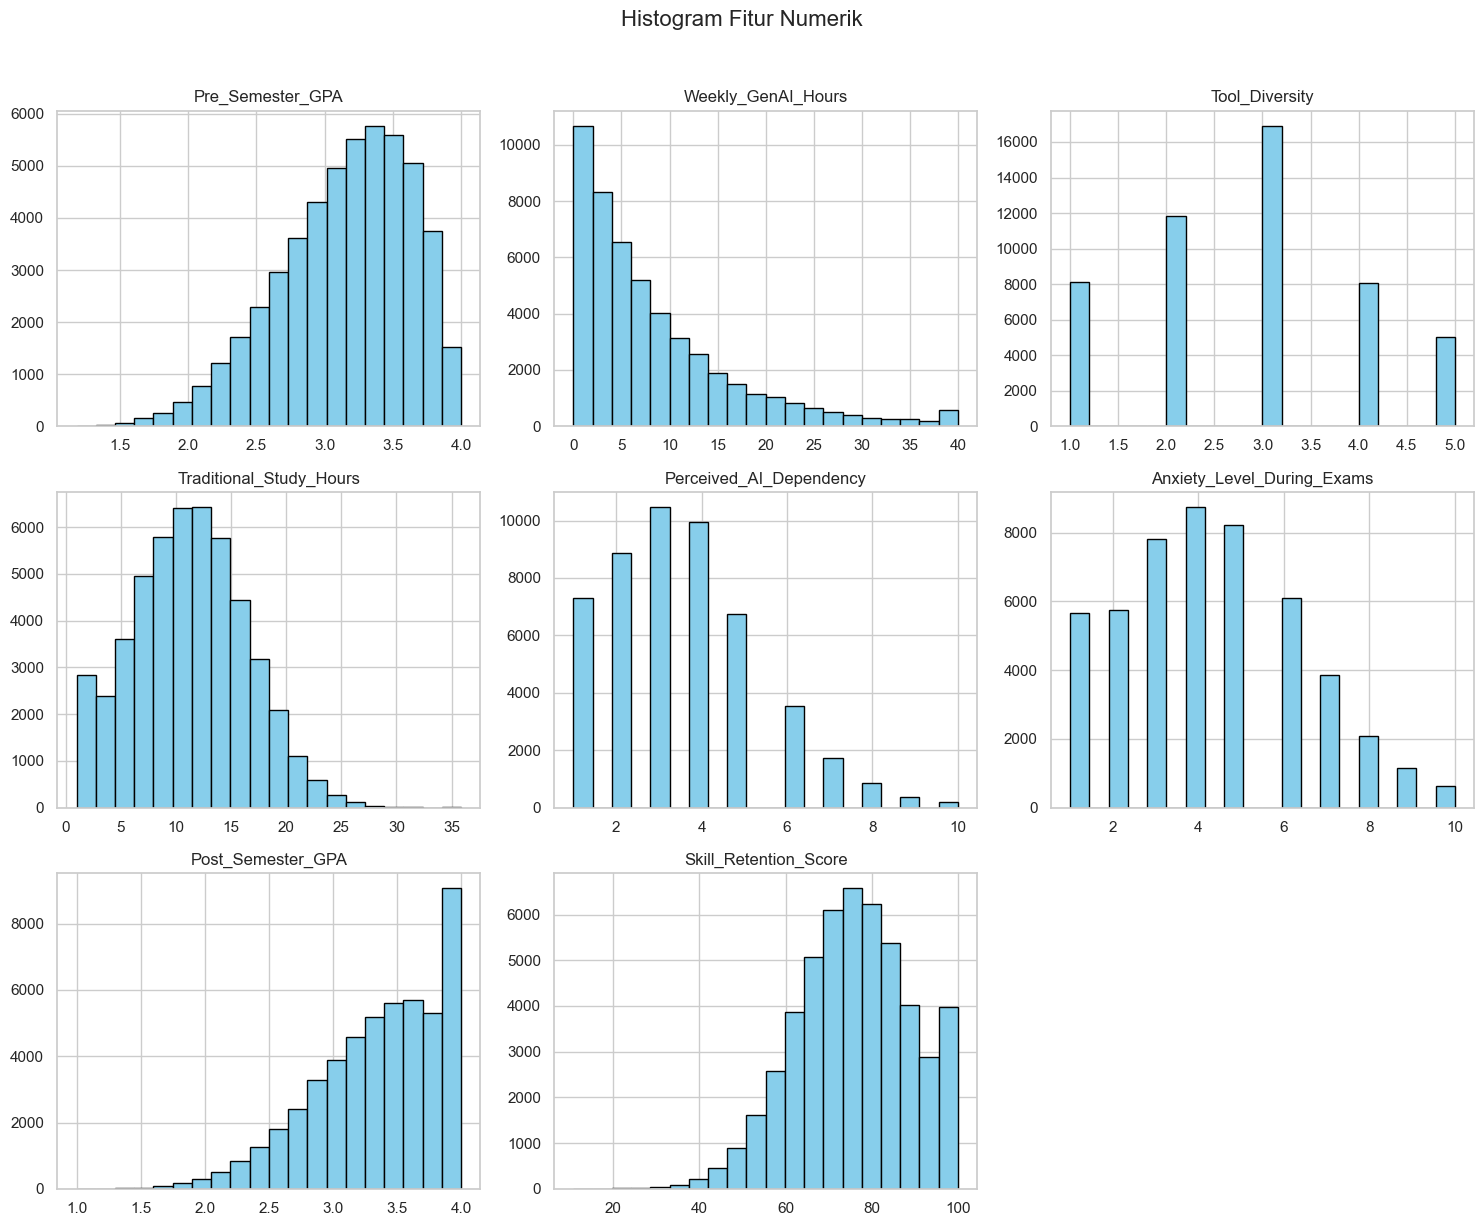

In [87]:
print("Menampilkan Histogram untuk fitur numerik...")
df[num_cols].hist(bins=20, figsize=(15, 12), color="skyblue", edgecolor="black")
plt.suptitle("Histogram Fitur Numerik", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Hubungan Fitur Numerik dengan Target (Boxplot)

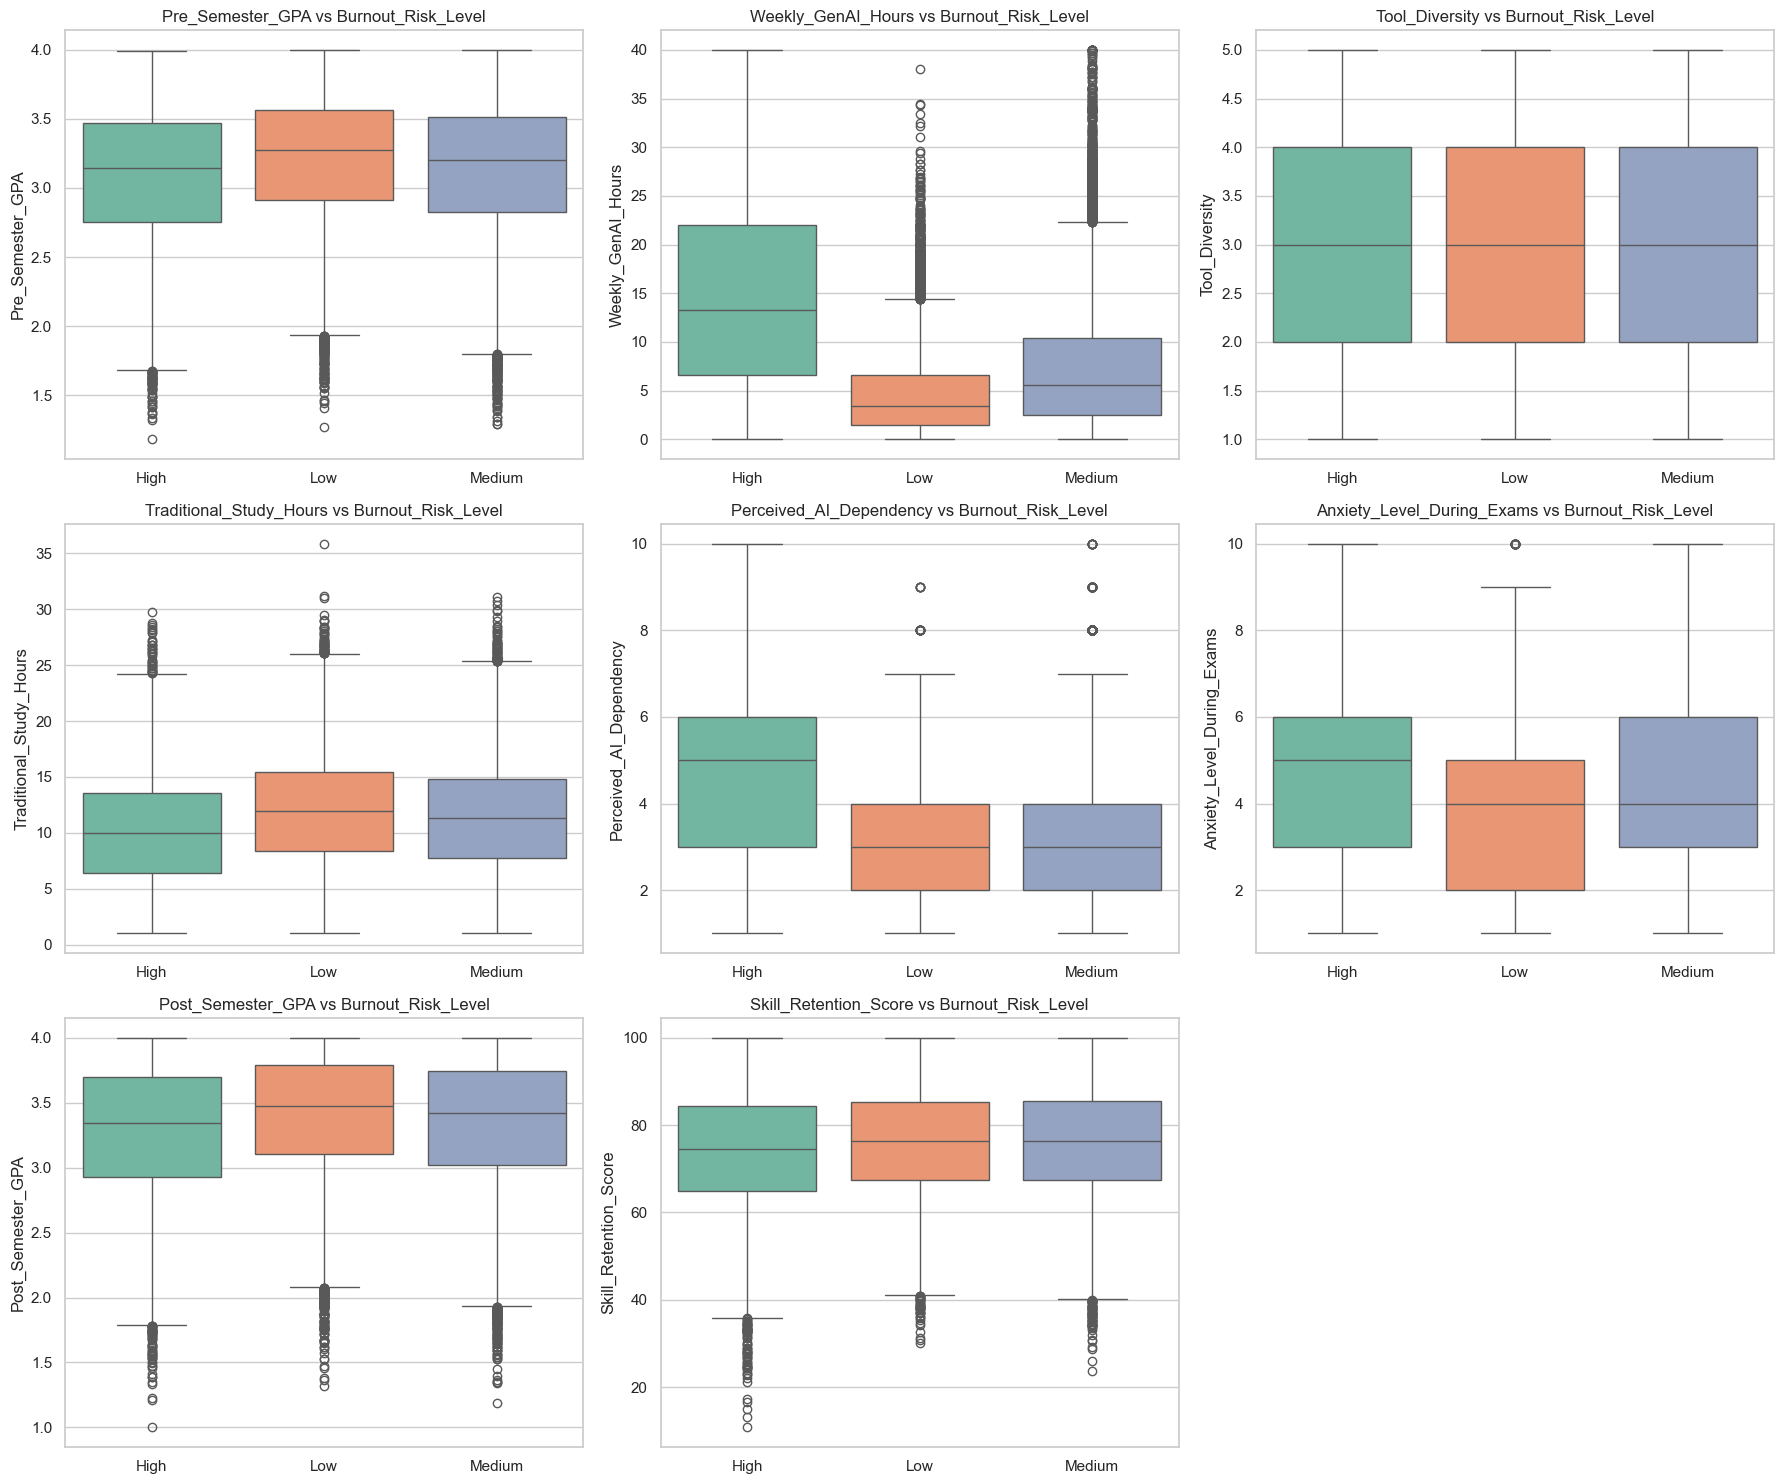

In [88]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[i],
        hue=target_col,
        palette="Set2",
        legend=False,
    )
    axes[i].set_title(f"{col} vs {target_col}")
    axes[i].set_xlabel("")

# Menghapus subplot yang kosong jika jumlah fitur ganjil/kurang dari grid
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Countplot Fitur Kategorikal (Berdasarkan Target)

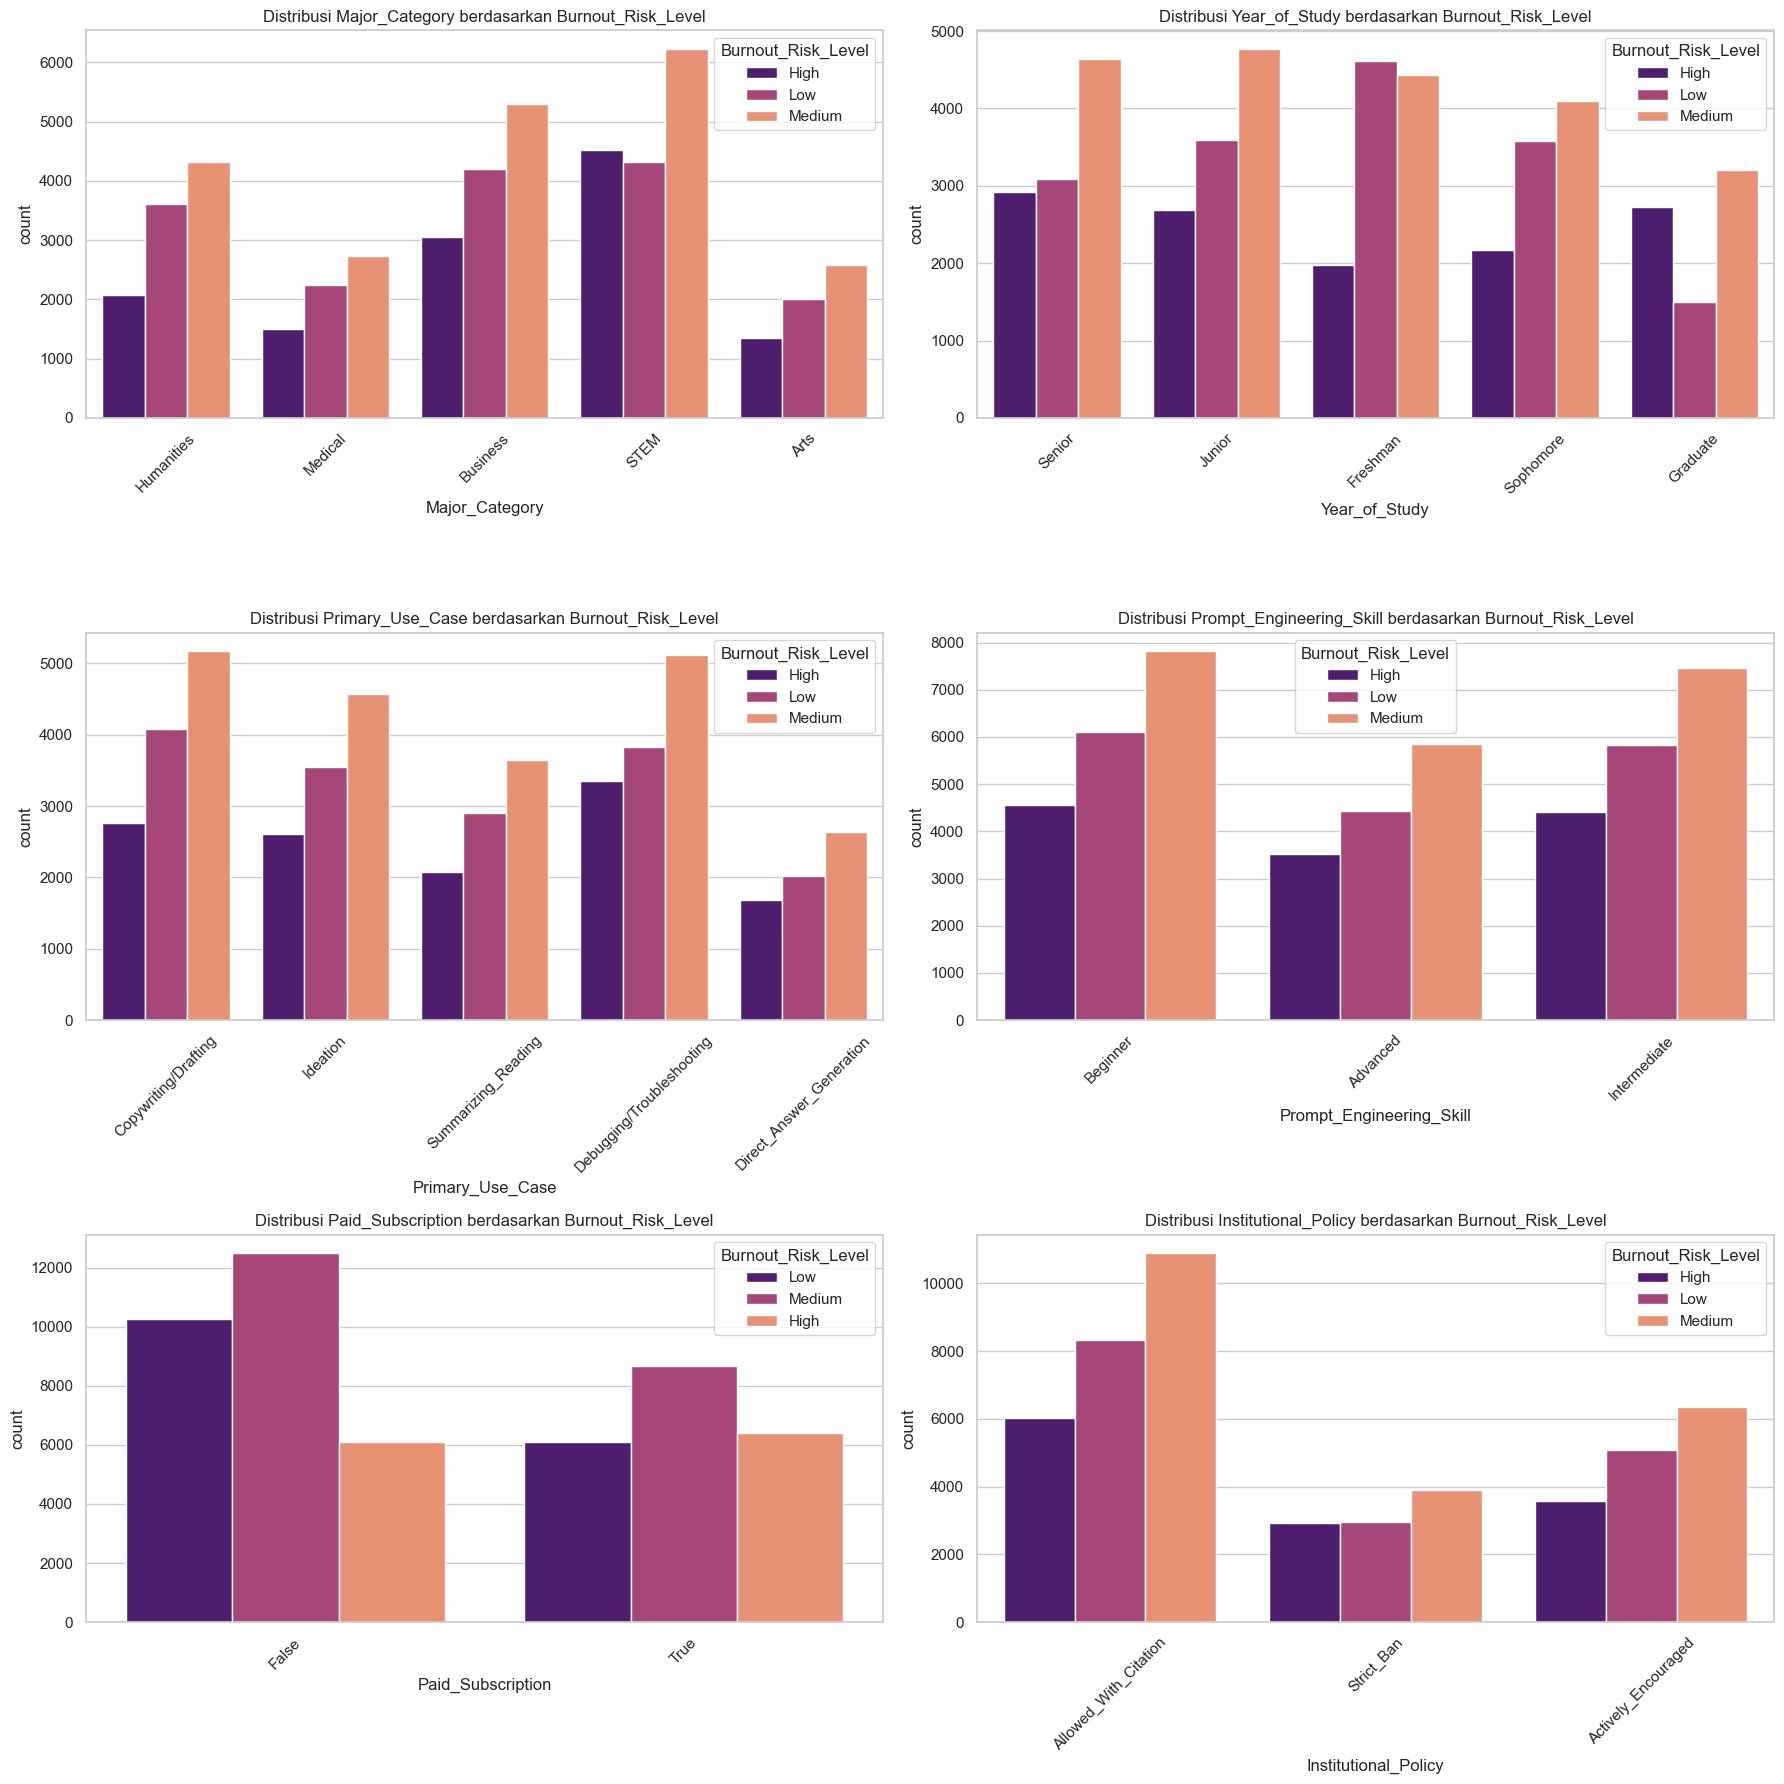

In [89]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette="magma")
    axes[i].set_title(f"Distribusi {col} berdasarkan {target_col}")
    axes[i].tick_params(axis="x", rotation=45)  # Memutar label X agar mudah dibaca

plt.tight_layout()
plt.show()

## Heatmap Korelasi Numerik

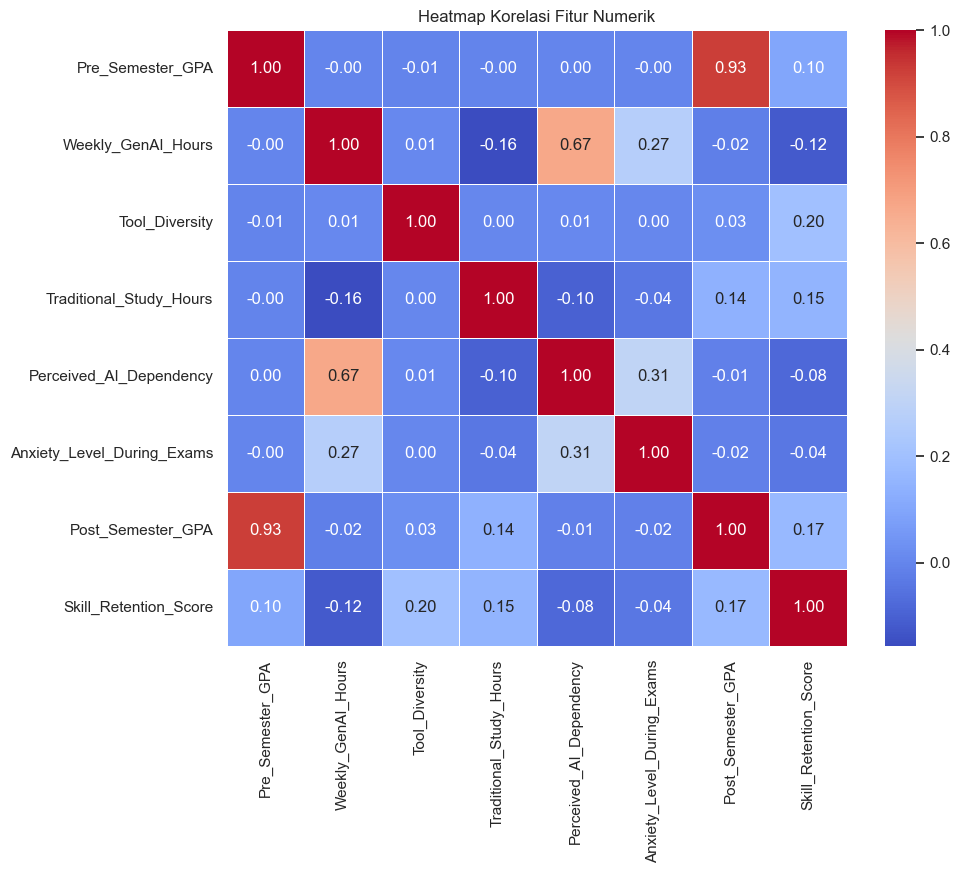

In [90]:
plt.figure(figsize=(10, 8))
# Hitung korelasi hanya untuk kolom numerik
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## Menangani Data Kosong & Duplikat

In [91]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [92]:
df_bersih = df.dropna()

In [93]:
df_bersih.duplicated().sum()

np.int64(0)

In [94]:
df_bersih.drop_duplicates(inplace=True)

## Menghapus Kolom Tidak Relevan & Memisahkan Target

In [95]:
# Hapus kolom yang tidak memiliki nilai prediktif
if "Student_ID" in df_bersih.columns:
    df_bersih = df_bersih.drop(columns=["Student_ID"])

# Encoding manual untuk target (Burnout_Risk_Level) karena sifatnya Ordinal
target_mapping = {"Low": 0, "Medium": 1, "High": 2}
df_bersih["Burnout_Risk_Level"] = df_bersih["Burnout_Risk_Level"].map(target_mapping)

# Pisahkan antara Fitur (X) dan Target (y)
X = df_bersih.drop(columns=[target_col])
y = df_bersih[target_col]

print(f"Shape X: {X.shape}, Shape y: {y.shape}")

Shape X: (50000, 14), Shape y: (50000,)


## Split Data

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 40000
Jumlah data uji: 10000


## Transformasi Kolom

In [97]:
# Buat Pipeline Transformasi
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# Fit dan Transform pada Data Latih (X_train)
X_train_processed = preprocessor.fit_transform(X_train)

# HANYA Transform pada Data Uji (X_test) untuk mencegah leakage
X_test_processed = preprocessor.transform(X_test)

# Ambil nama kolom baru hasil OneHotEncoding agar output tetap berupa DataFrame Pandas
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(
    cat_cols
)
all_feature_names = num_cols + cat_feature_names.tolist()

# Konversi kembali array numpy menjadi DataFrame yang rapi
X_train_clean = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_clean = pd.DataFrame(X_test_processed, columns=all_feature_names)

X_train_clean.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Major_Category_Arts,Major_Category_Business,...,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Paid_Subscription_False,Paid_Subscription_True,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,0.636719,2.329834,1.011692,-0.330753,0.270495,0.806848,0.679302,-0.616428,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,-0.324311,-0.789386,0.168229,-0.303570,0.270495,0.806848,-0.399045,1.360358,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2,0.078904,-0.110192,-1.518697,1.902155,0.270495,2.205239,0.501597,0.797068,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3,-0.483090,-0.718083,0.168229,0.275045,0.270495,0.340718,-0.980625,-1.161645,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.113302,-0.000215,-0.675234,0.535227,0.819056,1.272978,-0.413180,-1.319788,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## Menyimpan Dataset Preprocessing

In [98]:
# Buat folder penyimpanan jika belum ada
output_dir = "ai_impact_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# Gabungkan kembali X dan y untuk disimpan sebagai data latih dan data uji yang utuh
train_data_clean = pd.concat([X_train_clean, y_train.reset_index(drop=True)], axis=1)
test_data_clean = pd.concat([X_test_clean, y_test.reset_index(drop=True)], axis=1)

# Simpan ke dalam format CSV
train_data_clean.to_csv(f"{output_dir}/train_processed.csv", index=False)
test_data_clean.to_csv(f"{output_dir}/test_processed.csv", index=False)

print("Proses preprocessing selesai. Data berhasil disimpan di folder:", output_dir)

Proses preprocessing selesai. Data berhasil disimpan di folder: ai_impact_preprocessing
